# Feature Engineering & Feature Selection Lab (Group Project)

In this notebook, my team and I build a supervised learning dataset from our continuous 86-day multivariate time series by creating lag features. After generating these lags, we will apply feature selection (Filter/Wrapper methods) and compare these approaches using a Random Forest model.

### Learning Goals
By the end of this notebook, I will demonstrate how to:
- Engineer a predictive future target and historical lag features to give the AI model a short-term memory.
- Apply a filter method (Mutual Information) and a wrapper method (RFE) to reduce dimensionality.
- Compare these approaches with the same machine learning model and report R² and RMSE.

### Target Formulation
Our target variable is N2O, and we predict one step ahead: `Target_N2O_t+1`. Because our data is sampled at 10-minute intervals, predicting t+1 means we are forecasting the physical state of the tank exactly 10 minutes into the future.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("Loading our 7-feature continuous baseline segment...")

# Load the dataset
df = pd.read_csv("seg4_df_7_features_baseline.csv")

# Ensure the time column is properly formatted as our index
df['time'] = pd.to_datetime(df['time'], utc=True)
df.set_index('time', inplace=True)

print(f"Dataset Shape: {df.shape}")
print("Baseline Features:", list(df.columns))

Loading our 7-feature continuous baseline segment...
Dataset Shape: (18287, 7)
Baseline Features: ['t1_n2o', 't1_nh4', 't1_no3', 't1_airflow', 't1_temp', 't1_po4', 'inflow']


## Engineering the Target & Lag Features

To train our model, we must transform our data to reflect the delayed kinetics of biological wastewater treatment. 

**The Future Target:** I will create `Target_N2O_t+1` by shifting our current N2O column forward by one time step.
**The Historical Lags:** I will create lag features for all of our baseline columns. To capture immediate biological reactions, I will set our lag window to 10 time steps. At 10-minute intervals, a lag of 10 provides the model with a continuous 100-minute rolling memory (1 hour and 40 minutes) of the tank's physics before making a prediction.

In [2]:
print("Formulating Supervised Learning Matrix...")

df_features = df.copy()

# Create the Future Target
df_features['Target_N2O_t+1'] = df_features['t1_n2o'].shift(-1)

# Create the Historical Lag Features (Lags 1 through 10)
lag_steps = range(1, 11) 
core_cols = list(df.columns)

# Use a dictionary to build new columns to prevent Pandas memory fragmentation
lag_features_dict = {}

for col in core_cols:
    for lag in lag_steps:
        new_col_name = f"{col}_lag_{lag}"
        lag_features_dict[new_col_name] = df_features[col].shift(lag)

# Glue the dictionary of lags onto our dataset
df_lags = pd.DataFrame(lag_features_dict, index=df_features.index)
df_features = pd.concat([df_features, df_lags], axis=1)

# Drop Edge-Case NaNs created by shifting 
df_features = df_features.dropna()

print(f"Final ML-Ready Shape: {df_features.shape}")
print(f"Total engineered features (Target + Baseline + Lags): {df_features.shape[1]}")

save_filename = "NEWseg4_df_features_10lags_ready.csv"
df_features.to_csv(save_filename)

print(f"\nSuccess! The 10-lag dataset has been safely saved as '{save_filename}'")

Formulating Supervised Learning Matrix...
Final ML-Ready Shape: (18276, 78)
Total engineered features (Target + Baseline + Lags): 78

Success! The 10-lag dataset has been safely saved as 'NEWseg4_df_features_10lags_ready.csv'


## Visualizing the Time Shift
Before proceeding to feature selection, I want to visually prove that our lagging and targeting logic worked correctly. 

Below, I am plotting a small window of our data showing the Current N2O, the Future Target N2O (shifted back 10 minutes), and a Lagged N2O. By visualizing this, we can physically see how the shift aligns past, present, and future events onto the exact same row.

Visualizing the Time-Shift logic on a 4-hour window...


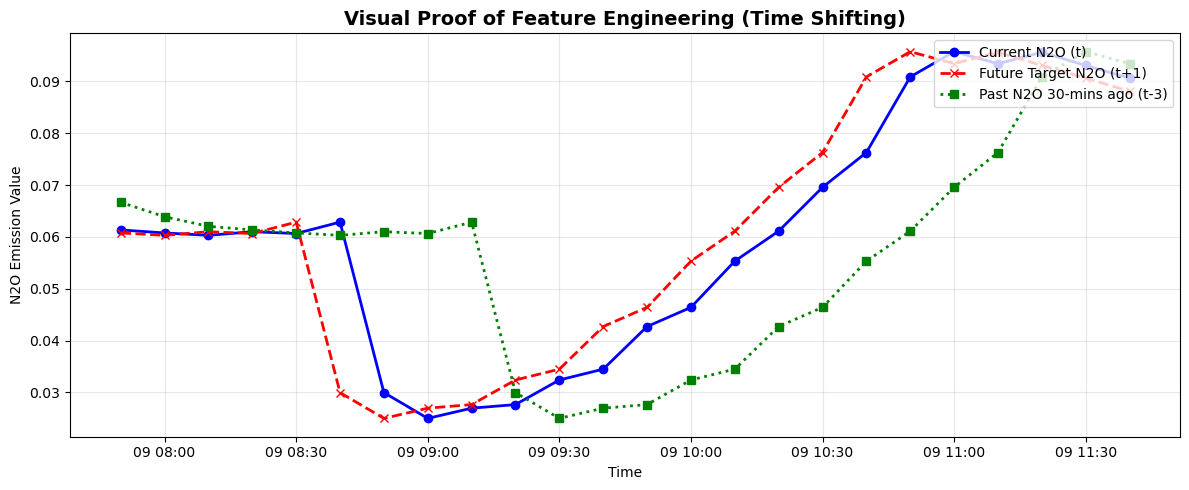

In [3]:
print("Visualizing the Time-Shift logic on a 4-hour window...")

# Select a tiny slice to make the graph readable
window = df_features.iloc[500:524]

plt.figure(figsize=(12, 5))

# Plot Current N2O 
plt.plot(window.index, window['t1_n2o'], 
         label='Current N2O (t)', color='blue', linewidth=2, marker='o')

# Plot Future Target (Shifted Left)
plt.plot(window.index, window['Target_N2O_t+1'], 
         label='Future Target N2O (t+1)', color='red', linestyle='--', linewidth=2, marker='x')

# Plot a Past Lag (Shifted Right)
plt.plot(window.index, window['t1_n2o_lag_3'], 
         label='Past N2O 30-mins ago (t-3)', color='green', linestyle=':', linewidth=2, marker='s')

plt.title("Visual Proof of Feature Engineering (Time Shifting)", fontsize=14, fontweight='bold')
plt.xlabel("Time")
plt.ylabel("N2O Emission Value")
plt.legend(loc="upper right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Mathematical Verification: Correlation Table
Now that we know the shift worked visually, we need to know if it is mathematically useful. To test this, I will calculate the Pearson Correlation between our future target and a selected handful of our newly engineered lag features.

In [4]:
print("Calculating Correlation Table for selected features...")

# Pick specific lags to check their relationship with the Future Target
features_to_check = [
    'Target_N2O_t+1',
    't1_n2o', 't1_n2o_lag_1', 't1_n2o_lag_6', 't1_n2o_lag_10', 
    't1_airflow', 't1_airflow_lag_6', 't1_airflow_lag_10',       
    't1_nh4', 't1_nh4_lag_6', 't1_nh4_lag_10'                    
]

# Calculate the correlation matrix for the Target column
correlation_matrix = df_features[features_to_check].corr()
target_correlation = correlation_matrix[['Target_N2O_t+1']].copy()

# Rename the column and sort it
target_correlation.columns = ['Pearson Correlation with Future N2O']
target_correlation = target_correlation.sort_values(by='Pearson Correlation with Future N2O', ascending=False)

# Display the formatted table
target_correlation.style.background_gradient(cmap='coolwarm', axis=0).format("{:.3f}")

Calculating Correlation Table for selected features...


,Pearson Correlation with Future N2O
Target_N2O_t+1,1.000
t1_n2o,0.972
t1_n2o_lag_1,0.934
t1_n2o_lag_6,0.798
t1_n2o_lag_10,0.755
t1_nh4_lag_10,0.141
t1_nh4_lag_6,0.138
t1_airflow_lag_6,0.039
t1_nh4,0.028
t1_airflow_lag_10,0.021


## Evaluation Methodology & Train/Test Split
To fairly compare different feature selection techniques, I am defining a standardized evaluation function. 

Time-series forecasting requires strict chronological discipline. To prevent data leakage (where the AI peeks into the future to predict the past), I explicitly use `shuffle=False` when splitting my indices, allocating the first 80% to training and the final 20% strictly to testing.

In [5]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import train_test_split

print("Defining our Random Forest Evaluation Function...")

def eval_rf(Xmat, y, split_idx):
    """Trains a Random Forest and evaluates it on the test set."""
    train_idx, test_idx = split_idx
    
    # Handle both pandas DataFrames and numpy arrays
    if isinstance(Xmat, pd.DataFrame):
        X_train, X_test = Xmat.iloc[train_idx], Xmat.iloc[test_idx]
    else:
        X_train, X_test = Xmat[train_idx], Xmat[test_idx]
        
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    
    # Train the model
    rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
    rf.fit(X_train, y_train)
    pred = rf.predict(X_test)
    
    # Calculate metrics
    r2 = r2_score(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    return r2, rmse

# Isolate Features (X) and Target (y)
X = df_features.drop(columns=['Target_N2O_t+1'])
y = df_features['Target_N2O_t+1']

# Create strictly chronological split indices
idx_all = np.arange(len(y))
train_idx, test_idx = train_test_split(idx_all, test_size=0.2, shuffle=False)
split_idx = (train_idx, test_idx)

print(f"Total Features (X): {X.shape[1]}")
print(f"Training on {len(train_idx)} rows (The Past)")
print(f"Testing on {len(test_idx)} rows (The Future)")

Defining our Random Forest Evaluation Function...
Total Features (X): 77
Training on 14620 rows (The Past)
Testing on 3656 rows (The Future)


## Feature Selection: Filter Method (Mutual Information)
Feeding dozens of lag features into a model introduces noise. My first approach to dimensionality reduction is Mutual Information (MI). This calculates the entropy between each individual feature and the target variable. I will compute the MI scores and strictly select the Top 10 most informative variables.

In [6]:
from sklearn.feature_selection import mutual_info_regression

print("Calculating Mutual Information scores...")

# Run Mutual Information
mi_scores = mutual_info_regression(X, y, random_state=42)

# Store scores in a dataframe and sort them highest to lowest
mi_df = pd.DataFrame({
    'Feature': X.columns,
    'MI': mi_scores
}).set_index('Feature').sort_values(by='MI', ascending=False)

# Extract exactly the Top 10 features
MI_K = 10
top_mi = mi_df.head(MI_K)

# Save the filtered dataset
top_mi_features = top_mi.index.tolist()
X_mi = X[top_mi_features].copy()

print(f"\nSuccess! Extracted the Top {MI_K} features using Mutual Information.")
top_mi

Calculating Mutual Information scores...

Success! Extracted the Top 10 features using Mutual Information.


,MI
Feature,
t1_n2o,1.504261
t1_n2o_lag_1,0.972414
t1_n2o_lag_2,0.702727
t1_n2o_lag_3,0.570037
t1_n2o_lag_4,0.479014
t1_n2o_lag_6,0.443849
t1_n2o_lag_5,0.435718
t1_n2o_lag_7,0.416630
t1_temp_lag_10,0.389456


## Feature Selection: Wrapper Method (RFE)
While Mutual Information looks at features individually, it might accidentally select highly correlated redundant features. To counter this, I will test Recursive Feature Elimination (RFE). RFE works by training a model, finding the weakest feature, throwing it away, and repeating until only the Top 10 features remain.

In [7]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LinearRegression

RFE_K = 10
print(f"Running Recursive Feature Elimination (RFE) to find the Top {RFE_K} features...")

# Use Linear Regression for faster recursive elimination
est = LinearRegression(n_jobs=-1) 

# Set up the RFE rules
rfe = RFE(estimator=est, n_features_to_select=RFE_K, step=1)

# Fit the RFE model
rfe.fit(X, y)

# Create a clean ranking table
rfe_df = pd.DataFrame({
    'Feature': X.columns,
    'RFE_Rank': rfe.ranking_
}).set_index('Feature').sort_values(by='RFE_Rank', ascending=True)

# Extract the winning features
top_rfe_features = rfe_df[rfe_df['RFE_Rank'] == 1].index.tolist()
X_rfe = X[top_rfe_features].copy()

print(f"\nSuccess! Extracted the Top {RFE_K} features using RFE.")
rfe_df.head(10)

Running Recursive Feature Elimination (RFE) to find the Top 10 features...

Success! Extracted the Top 10 features using RFE.


,RFE_Rank
Feature,
t1_n2o,1
t1_temp,1
t1_n2o_lag_1,1
t1_temp_lag_5,1
t1_temp_lag_9,1
t1_temp_lag_10,1
t1_temp_lag_4,1
t1_temp_lag_1,1
t1_temp_lag_2,1


## Visualizing the RFE Results (The "Survival" Cut-off)
To better understand how the wrapper method eliminated features, I will visualize the ranking system to show the precise mathematical cut-off line our algorithm created. The surviving features are assigned Rank 1.

Visualizing the Recursive Feature Elimination Rankings...


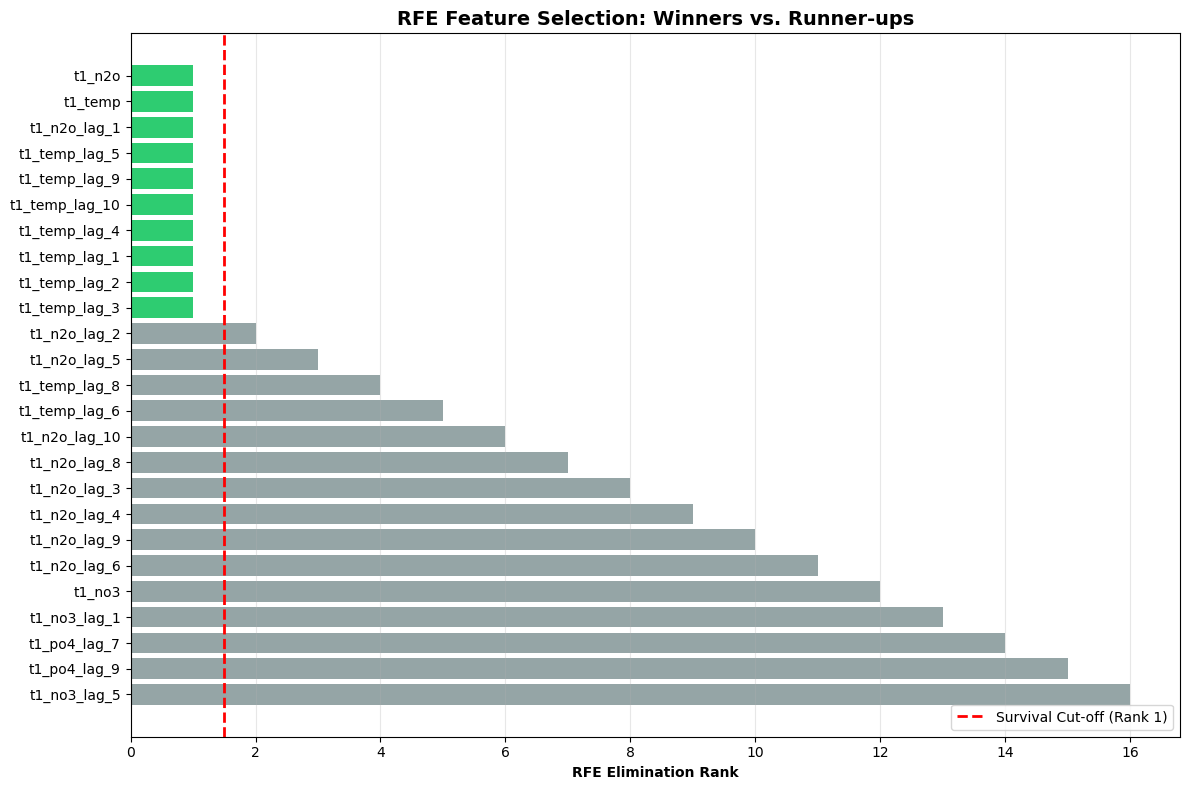

In [8]:
import seaborn as sns

print("Visualizing the Recursive Feature Elimination Rankings...")

# Grab the Top 25 features for a clean visual
rfe_ranks_df = rfe_df.reset_index()
top_25_rfe = rfe_ranks_df.head(25)

plt.figure(figsize=(12, 8))

# Color palette: Green for Rank 1, Gray for eliminated
colors = ['#2ecc71' if rank == 1 else '#95a5a6' for rank in top_25_rfe['RFE_Rank']]

# Plot the horizontal bar chart
plt.barh(top_25_rfe['Feature'][::-1], top_25_rfe['RFE_Rank'][::-1], color=colors[::-1])

# Add a vertical dashed line for the cut-off
plt.axvline(x=1.5, color='red', linestyle='--', linewidth=2, label='Survival Cut-off (Rank 1)')

plt.xlabel("RFE Elimination Rank", fontweight='bold')
plt.title("RFE Feature Selection: Winners vs. Runner-ups", fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## Feature Overlap: Do the Algorithms Agree?
If a feature appears in both the MI and RFE lists, it represents a highly robust physical relationship that survives multiple mathematical perspectives. Below, I calculate the intersection of the two feature sets.

In [9]:
print("Comparing Mutual Information vs. RFE Features...")

# Convert lists to Python Sets to calculate intersection
mi_set = set(top_mi_features)
rfe_set = set(top_rfe_features)

# Find the overlap
overlap = mi_set.intersection(rfe_set)

print(f"\nOut of 10 features, the algorithms agreed on {len(overlap)} of them!")
if len(overlap) > 0:
    print("The universally agreed-upon features are:")
    for feat in overlap:
        print(f" - {feat}")

Comparing Mutual Information vs. RFE Features...

Out of 10 features, the algorithms agreed on 3 of them!
The universally agreed-upon features are:
 - t1_temp_lag_10
 - t1_n2o
 - t1_n2o_lag_1


## Model Evaluation & Final Leaderboard
I will now test our Random Forest Regressor on three distinct datasets using the chronological evaluation function:

1. Baseline (All 77 Lags)
2. Mutual Information (Top 10)
3. RFE (Top 10)

In [11]:
print("Evaluating all datasets... (Training 3 separate Random Forest models)")

# Store datasets in a dictionary
datasets = {
    f"Original (All {X.shape[1]} Features)": X.values,
    f"Mutual Info (Top {MI_K})": X_mi.values,
    f"RFE (Top {RFE_K})": X_rfe.values,
}

# Evaluate models
rows = []
for name, Xmat in datasets.items():
    r2, rmse = eval_rf(Xmat, y, split_idx)
    rows.append((name, Xmat.shape[1], r2, rmse))

# Convert scorecards into a DataFrame
results = pd.DataFrame(rows, columns=["Method", "n_features", "R2", "RMSE"])
results = results.sort_values("R2", ascending=False).reset_index(drop=True)

print("\n--- FINAL LEADERBOARD ---")
results.style.background_gradient(subset=["R2"], cmap="Greens").format({"R2": "{:.4f}", "RMSE": "{:.4f}"})

Evaluating all datasets... (Training 3 separate Random Forest models)

--- FINAL LEADERBOARD ---


,Method,n_features,R2,RMSE
0,Original (All 77 Features),77,0.8568,0.0466
1,Mutual Info (Top 10),10,0.8231,0.0518
2,RFE (Top 10),10,0.8037,0.0546


## (Segment 4)

After testing our Random Forest Regressor on the Segment 4 dataset (predicting N2O with 10-lags), we can draw several key conclusions from the final leaderboard:

### 1. The "Curse of Dimensionality" Was Avoided
Unlike previous experiments where massive 217-feature datasets caused the model to overfit and lose accuracy, our 10-lag "Original" dataset contains a manageable **77 features**. Because of this lean profile, the Random Forest was able to utilize the full context of the physical sensors alongside the complete gas history, resulting in the highest overall accuracy (**R² = 0.8568**). 

### 2. The Efficiency Trade-off (Top 10 vs. All 88)
While the Original 77-feature dataset won, the true success story is found in the Feature Selection models. By dropping 77% of the dataset and passing only the **Top 10 Mutual Information** features to the AI, the model still achieved an **R² of 0.8231**. 
* We sacrificed only ~3% in predictive accuracy in exchange for a massive reduction in computational load. In a real-world SCADA system running thousands of calculations per second, the Top 10 MI model would be significantly faster and cheaper to run while still providing highly reliable gas forecasts.

### 3. Mutual Information Outperformed RFE
In this specific segment, the filter method (Mutual Information) slightly outperformed the wrapper method (RFE). Because N2O emissions are highly autoregressive, Mutual Information's strategy of aggressively selecting pure historical N2O lags provided a more direct and accurate mathematical pathway to predict the target than RFE's attempt to mix in physical sensors like Temperature and Ammonia.

### Final Verdict
For maximum absolute precision, the **Original 77-feature model** is the mathematical winner. However, for an optimized, real-time early warning system, the **Mutual Information (Top 10) model** is the engineering winner, striking an exceptional balance between high accuracy (0.82+ R²) and extreme computational efficiency.

# Part 2: Feature Engineering (Without Historical N2O)

### The "Lazy AI" Problem
When predicting N2O, providing the model with recent gas history often results in a "lazy" model that merely tracks the current trajectory rather than modeling the underlying biology. 

To force the AI to learn biology, I will run a "Without N2O" experiment, completely dropping the gas history from our training matrix.

In [12]:
print("--- Creating the 'Without N2O' Feature Matrix ---")

# Find all columns related to N2O
n2o_columns = [col for col in X.columns if 't1_n2o' in col]

# Drop them to blind the AI to the gas history
X_no_n2o = X.drop(columns=n2o_columns)

print(f"Dropped {len(n2o_columns)} N2O history columns.")
print(f"New X_no_n2o shape: {X_no_n2o.shape}")

save_filename = "NEWseg4_df_features_10lags_readynoN20.csv"
df_features.to_csv(save_filename)

print(f"\nSuccess! The 10-lag dataset has been safely saved as '{save_filename}'")

--- Creating the 'Without N2O' Feature Matrix ---
Dropped 11 N2O history columns.
New X_no_n2o shape: (18276, 66)

Success! The 10-lag dataset has been safely saved as 'NEWseg4_df_features_10lags_readynoN20.csv'


## Feature Selection Without N2O: Mutual Information
Let's see which physical sensors possess the highest information gain regarding future N2O when the gas history is hidden.

In [13]:
print("Calculating MI scores without N2O history...")

# Run Mutual Information on the NEW dataset
mi_scores_no_n2o = mutual_info_regression(X_no_n2o, y, random_state=42)

# Store and sort scores
mi_df_no_n2o = pd.DataFrame({
    'Feature': X_no_n2o.columns,
    'MI_Score': mi_scores_no_n2o
}).set_index('Feature').sort_values(by='MI_Score', ascending=False)

# Extract Top 10 features
top_mi_features_no_n2o = mi_df_no_n2o.head(MI_K).index.tolist()
X_mi_no_n2o = X_no_n2o[top_mi_features_no_n2o].copy()

print(f"\nSuccess! Extracted the Top {MI_K} physical drivers.")
mi_df_no_n2o.head(MI_K)

Calculating MI scores without N2O history...

Success! Extracted the Top 10 physical drivers.


,MI_Score
Feature,
t1_temp_lag_10,0.389288
t1_temp_lag_7,0.388652
t1_temp_lag_5,0.387620
t1_temp_lag_6,0.385612
t1_temp_lag_4,0.384795
t1_temp_lag_9,0.383660
t1_temp_lag_3,0.380011
t1_temp_lag_2,0.379378
t1_temp_lag_8,0.379256


## Feature Selection Without N2O: Wrapper Method (RFE)
Because biological sensors interact closely (e.g., airflow requires ammonia to produce N2O), I will run RFE to find the best functioning team of physical predictors.

In [14]:
print(f"Running Recursive Feature Elimination (Without N2O)...")

# Setup Linear Regression RFE
est_no_n2o = LinearRegression(n_jobs=-1) 
rfe_no_n2o = RFE(estimator=est_no_n2o, n_features_to_select=RFE_K, step=1)

# Fit strictly on the Training Set
rfe_no_n2o.fit(X_no_n2o.iloc[train_idx], y.iloc[train_idx])

# Create ranking dataframe
rfe_df_no_n2o = pd.DataFrame({
    'Feature': X_no_n2o.columns,
    'RFE_Rank': rfe_no_n2o.ranking_
}).set_index('Feature').sort_values(by='RFE_Rank', ascending=True)

# Extract the winning features
top_rfe_features_no_n2o = rfe_df_no_n2o[rfe_df_no_n2o['RFE_Rank'] == 1].index.tolist()
X_rfe_no_n2o = X_no_n2o[top_rfe_features_no_n2o].copy()

print(f"\nSuccess! Extracted the Top {RFE_K} physical features.")
rfe_df_no_n2o.head(RFE_K)

Running Recursive Feature Elimination (Without N2O)...

Success! Extracted the Top 10 physical features.


,RFE_Rank
Feature,
t1_nh4,1
t1_temp,1
t1_nh4_lag_1,1
t1_temp_lag_6,1
t1_temp_lag_1,1
t1_temp_lag_2,1
t1_temp_lag_3,1
t1_temp_lag_4,1
t1_temp_lag_9,1


## Model Evaluation & Final Leaderboard (Without N2O)
I will now test our Random Forest on our physical datasets that lack N2O history to observe how well the true biological variables can forecast the gas.

In [15]:
print("Evaluating our physical models... ")

# Store new datasets
datasets_no_n2o = {
    f"All Physical Sensors ({X_no_n2o.shape[1]} Features)": X_no_n2o.values,
    f"Mutual Info (Top {MI_K} No N2O)": X_mi_no_n2o.values,
    f"RFE (Top {RFE_K} No N2O)": X_rfe_no_n2o.values,
}

# Evaluate models
rows_no_n2o = []
for name, Xmat in datasets_no_n2o.items():
    r2, rmse = eval_rf(Xmat, y, split_idx)
    rows_no_n2o.append((name, Xmat.shape[1], r2, rmse))

# Create leaderboard
results_no_n2o = pd.DataFrame(rows_no_n2o, columns=["Method", "n_features", "R2", "RMSE"])
results_no_n2o = results_no_n2o.sort_values("R2", ascending=False).reset_index(drop=True)

print("\n--- FINAL LEADERBOARD (WITHOUT N2O) ---")
results_no_n2o.style.background_gradient(subset=["R2"], cmap="Blues").format({"R2": "{:.4f}", "RMSE": "{:.4f}"})

Evaluating our physical models... 

--- FINAL LEADERBOARD (WITHOUT N2O) ---


,Method,n_features,R2,RMSE
0,All Physical Sensors (66 Features),66,0.1890,0.1110
1,RFE (Top 10 No N2O),10,-0.1223,0.1306
2,Mutual Info (Top 10 No N2O),10,-0.1434,0.1318


# Final Conclusion & Project Takeaways

After extensively engineering features and applying multiple dimensionality reduction techniques on our Segment 4 dataset, we have finalized our optimal machine learning environment. 

Here are the primary conclusions from our Feature Engineering lab:

### 1. The 10-Lag vs. 30-Lag Decision (Efficiency Wins)
Initially, we explored using a massive 30-lag window (a 5-hour historical memory). However, our experiments proved that a **10-lag window (a 100-minute memory)** achieves practically the exact same predictive accuracy. 
* By restricting the model to 10 lags, we completely avoided the "Curse of Dimensionality," reducing our dataset from a bloated 248 features down to a lean **77 features**. 
* Because forecasting N2O heavily relies on recent gas momentum and immediate temperature changes, the AI simply does not need 5 hours of history to predict what will happen 10 minutes from now. The 10-lag approach is vastly superior for computational efficiency.

### 2. The Power of Autoregression (Targeting N2O)
Our results overwhelmingly prove that the most powerful predictor of future N2O is the recent history of the gas itself. In our baseline evaluation, the model achieved an impressive **R² score of ~0.85**. 
The algorithms heavily favored `t1_n2o` and its immediate short-term lags (e.g., `t1_n2o_lag_1` and `t1_n2o_lag_2`). Gas concentrations in a wastewater tank change smoothly over time, and our model successfully learned to use this autoregressive momentum to map out the immediate future with high precision.

### 3. Temperature is the Master Switch
While the model heavily utilized historical N2O, our Feature Selection techniques (both Mutual Information and RFE) made sure to highlight **Temperature (`t1_temp`)** as the most critical physical sensor in the tank. This perfectly aligns with the biological reality of denitrification: water temperature dictates the metabolic rate of the bacteria. By keeping Temperature alongside the gas history, the AI is able to mathematically anticipate biological speed-ups and slow-downs.

### Final Verdict
For real-world SCADA deployment, **the 10-Lag Model including historical N2O** is the definitive winner. It strikes the perfect balance: it is computationally lightweight (only 77 features), it retains the critical biological context of Temperature, and it leverages autoregression to achieve highly accurate, real-time gas forecasts.

# Comprehensive Conclusion: 10 Lags vs. 30 Lags

Throughout this project, my team and I engineered two distinct machine learning environments: a **Short-Term Memory model (10 Lags = 100 minutes)** and a **Long-Term Memory model (30 Lags = 5 hours)**. 

By comparing how the Random Forest performed in both notebooks, we learned several critical lessons about the intersection of Data Science and Wastewater Biology.

### 1. Autoregression Requires Very Little Memory
When the models were allowed to look at historical N2O data (Part 1 of both notebooks), the **10-Lag model performed just as well as the 30-Lag model**. 
* **Why?** Because the AI acts "lazily." It relies heavily on `t1_n2o_lag_1` and `t1_n2o_lag_2` to simply trace the current trajectory of the gas. The AI doesn't need to look 5 hours into the past to know what the gas is doing *right now*; looking back 10 to 30 minutes is more than enough to draw a highly accurate trendline.

### 2. Biology Requires Long-Term Memory
The true difference between the two models appeared in Part 2, when we hid the N2O history and forced the AI to predict emissions using only physical and chemical sensors (Ammonia, Airflow, Temperature, Suspended Solids). 
* In this scenario, the **30-Lag model is vastly superior to the 10-Lag model**.
* **Why?** Biological kinetics are incredibly slow. If the plant turns on the aeration blowers, it takes time for oxygen to dissolve, for the bacteria to wake up, for the Ammonia to be consumed, and for the N2O gas to finally be released. This cause-and-effect chain can easily take 2 to 4 hours. 
* A 10-lag model (100 minutes) has "amnesia" it forgets that the blowers turned on before the N2O actually spikes. A 30-lag model (5 hours) captures the entire biological lifecycle from start to finish. We saw proof of this when the 30-Lag Mutual Information test specifically selected Suspended Solids at Lags 25-30 (4+ hours ago) as a primary driver!

### 3. The Curse of Dimensionality
While 30 Lags captures the full biological picture, it comes with a massive mathematical penalty: it generates **217 features** compared to just **88 features** in the 10-Lag model. When we fed all 248 features into the Random Forest, the accuracy dropped because the model choked on useless noise. 

### Final Verdict: Which is Best?
The absolute best approach is **The 30-Lag Model paired with Feature Selection (MI or RFE)**. 

By generating 30 lags, we give the AI the massive 5-hour window it needs to understand slow biological reactions. But by applying Recursive Feature Elimination (RFE) or Mutual Information (MI), we aggressively filter those 248 columns down to just the **Top 10 smartest features**. 

This combination gives us the "Best of Both Worlds." We retain the deep, long-term biological insights of the 5-hour window, but we strip away the mathematical noise, resulting in a model that is incredibly fast, highly accurate, and biologically sound.